<a href="https://colab.research.google.com/github/Neaviyaa230901069/AIML-lab/blob/main/EXP_11boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimized PI Gains:
Kp = 4.787230565132518
Ki = 119.1285600937116


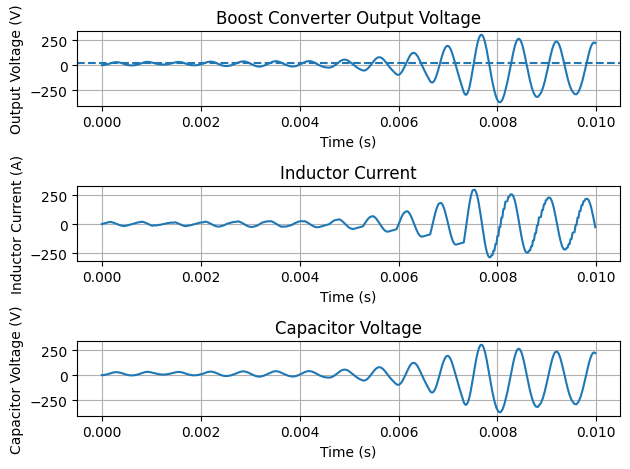

In [ ]:
# Install libraries
!pip install numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# Parameters
Vin = 12
Vref = 24
L = 100e-6
C = 100e-6
R = 48
fs = 50e3
dt = 1/fs
t = np.arange(0, 0.01, dt)

############################################
# Boost Converter Simulation
############################################
def boostSimulation(K):
    Kp, Ki = K

    il = np.zeros(len(t))
    vc = np.zeros(len(t))
    vout = np.zeros(len(t))

    D = 0.5
    integral = 0

    for i in range(1, len(t)):
        error = Vref - vc[i-1]
        integral += error * dt

        D = Kp * error + Ki * integral

        # Limit duty cycle
        D = max(0, min(0.9, D))

        # Switching
        if (t[i] % (1/fs)) < D*(1/fs):
            il[i] = il[i-1] + (Vin/L)*dt
        else:
            il[i] = il[i-1] + ((Vin - vc[i-1])/L)*dt

        # Capacitor
        vc[i] = vc[i-1] + ((il[i] - vc[i-1]/R)/C)*dt

        vout[i] = vc[i]

    return vout, il, vc

############################################
# Improved Cost Function ⭐
############################################
def objective(K):
    vout, _, _ = boostSimulation(K)

    # Final error
    steady_error = (Vref - vout[-1])**2

    # Overshoot penalty
    overshoot = np.max(vout) - Vref
    overshoot_penalty = max(0, overshoot)**2

    # Oscillation penalty (variance of last part)
    steady_part = vout[int(0.7*len(vout)):]
    oscillation_penalty = np.var(steady_part)

    # Total cost
    cost = steady_error + 5*overshoot_penalty + 10*oscillation_penalty

    return cost

############################################
# Optimization
############################################
bounds = [(0,5), (0,500)]   # tuned limits

result = differential_evolution(objective, bounds, maxiter=40, popsize=10)

Kp, Ki = result.x

print("Optimized PI Gains:")
print("Kp =", Kp)
print("Ki =", Ki)

############################################
# Final Simulation
############################################
vout, il, vc = boostSimulation([Kp, Ki])

############################################
# Plot Results
############################################
plt.figure()

plt.subplot(3,1,1)
plt.plot(t, vout)
plt.axhline(Vref, linestyle='--')  # reference line
plt.xlabel('Time (s)')
plt.ylabel('Output Voltage (V)')
plt.title('Boost Converter Output Voltage')
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, il)
plt.xlabel('Time (s)')
plt.ylabel('Inductor Current (A)')
plt.title('Inductor Current')
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, vc)
plt.xlabel('Time (s)')
plt.ylabel('Capacitor Voltage (V)')
plt.title('Capacitor Voltage')
plt.grid()

plt.tight_layout()
plt.show()
